# Projet Airbnb

Equipe: MOUAKHAR Hela et MOSSERI Déborah


## Objectif du projet 

Le but de ce projet est de prédire le prix de location d’un Airbnb à partir d’un ensemble de caractéristiques.


## I) Initialisation et chargement des données


In [394]:
import numpy as np
import pandas as pd

In [395]:
# Chargement des données
train_df = pd.read_csv('airbnb_train.csv')
test_df = pd.read_csv('airbnb_test.csv')

train_df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


Le chargment est réussi.

Nous avons une vue d'ensemble sur les données (colonnes) présentes, 

Nous allons donc maintenant faire la séparation entre les caracteristiques (X) et la cible (y)**

In [396]:
y_train = train_df["log_price"]

X_train = train_df.drop("log_price", axis=1)
X_test = test_df.copy() #il n'y a pas de colonne log_price dans test_airbnb

print("y_train : \n", y_train.head(),"\n \n X_train : \n", X_train.head(), "\n \n X_test : \n", X_test.head())

y_train : 
 0    4.317488
1    4.007333
2    7.090077
3    3.555348
4    5.480639
Name: log_price, dtype: float64 
 
 X_train : 
          id property_type        room_type  \
0   5708593         House     Private room   
1  14483613         House     Private room   
2  10412649     Apartment  Entire home/apt   
3  17954362         House     Private room   
4   9969781         House  Entire home/apt   

                                           amenities  accommodates  bathrooms  \
0  {TV,"Wireless Internet",Kitchen,"Free parking ...             3        1.0   
1  {"Wireless Internet","Air conditioning",Kitche...             4        2.0   
2  {TV,"Wireless Internet","Air conditioning",Kit...             6        2.0   
3  {TV,"Cable TV",Internet,"Wireless Internet","A...             1        1.0   
4  {TV,"Cable TV",Internet,"Wireless Internet",Ki...             4        1.0   

   bed_type cancellation_policy  cleaning_fee city  ... last_review  \
0  Real Bed            flexible    

## II) Exploration qualitative des données

Cette section a pour but de comprendre la structure des données et d'identifier les variables les plus corrélées au prix, afin de motiver nos choix de prétraitement.

Graphique 1: Distribution du log_price 

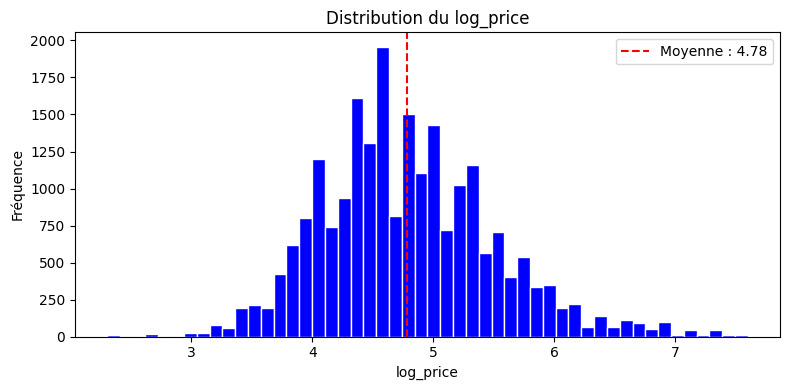

count    22234.000000
mean         4.783481
std          0.718758
min          2.302585
25%          4.317488
50%          4.700480
75%          5.220356
max          7.600402
Name: log_price, dtype: float64


In [397]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.hist(train_df['log_price'], bins=50, color='blue', edgecolor='white')
plt.axvline(train_df['log_price'].mean(), color='red', linestyle='--', label=f"Moyenne : {train_df['log_price'].mean():.2f}")
plt.xlabel('log_price')
plt.ylabel('Fréquence')
plt.title('Distribution du log_price')
plt.legend()
plt.tight_layout()
plt.show()

print(train_df['log_price'].describe())

La distribution du log_price suit une forme quasi-normale, centrée autour de 4.78 (soit environ 120$ par nuit). Cela valide l'utilisation du logarithme du prix comme variable cible : travailler en log permet de stabiliser la variance et de mieux capturer les relations linéaires avec les features.

Graphique 2 : Distribution du prix brut 

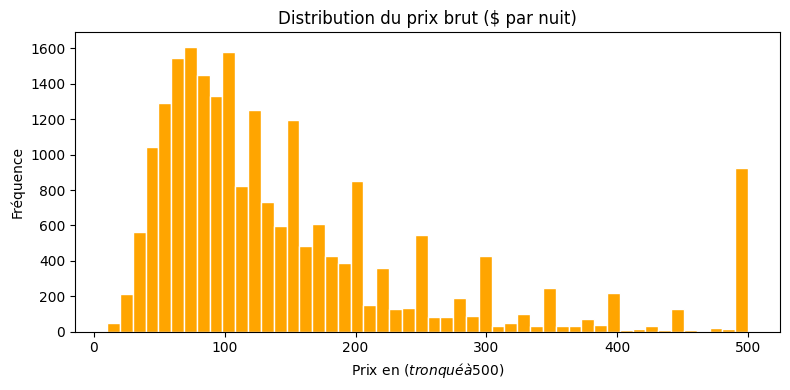

Prix médian : 110$
Prix moyen  : 161$


In [398]:
import numpy as np

prix_brut = np.exp(train_df['log_price'])

plt.figure(figsize=(8, 4))
plt.hist(prix_brut.clip(upper=500), bins=50, color='orange', edgecolor='white')
plt.xlabel('Prix en $ (tronqué à 500$)')
plt.ylabel('Fréquence')
plt.title('Distribution du prix brut ($ par nuit)')
plt.tight_layout()
plt.show()

print(f"Prix médian : {prix_brut.median():.0f}$")
print(f"Prix moyen  : {prix_brut.mean():.0f}$")

En repassant au prix brut, on observe une distribution fortement asymétrique à droite : la majorité des logements coûtent entre 50$ et 150$ par nuit, mais il existe des logements très chers qui tirent la moyenne vers le haut. C'est  pourquoi travailler avec le log_price est plus adapté pour la modélisation.

Graphique 4 : Boxplot prix par ville 


/var/folders/r_/65dhf1995rs2srj0d2ywplw80000gn/T/ipykernel_2907/1109722689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='city', y='log_price', order=order, palette='Set2')


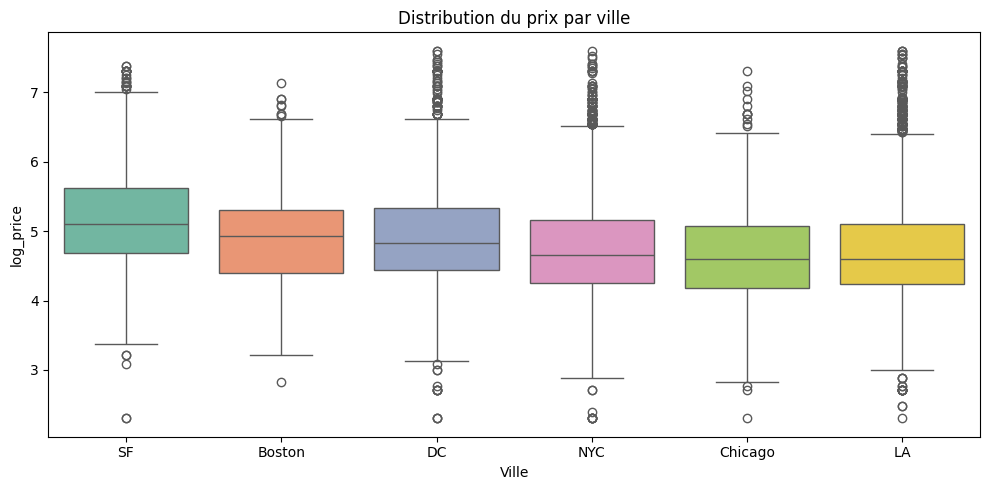

In [399]:
plt.figure(figsize=(10, 5))
order = train_df.groupby('city')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train_df, x='city', y='log_price', order=order, palette='Set2')
plt.xlabel('Ville')
plt.ylabel('log_price')
plt.title('Distribution du prix par ville')
plt.tight_layout()
plt.show()

San Francisco est la ville la plus chère avec la médiane la plus élevée et une dispersion relativement faible. Chicago est la moins chère. NYC et LA ont des dispersions plus importantes et davantage de valeurs extrêmes, ce qui reflète une plus grande hétérogénéité des logements. La ville est donc une variable pertinente à conserver pour la prédiction.

Graphique 5 :Top 20 quartiers NYC et SF 


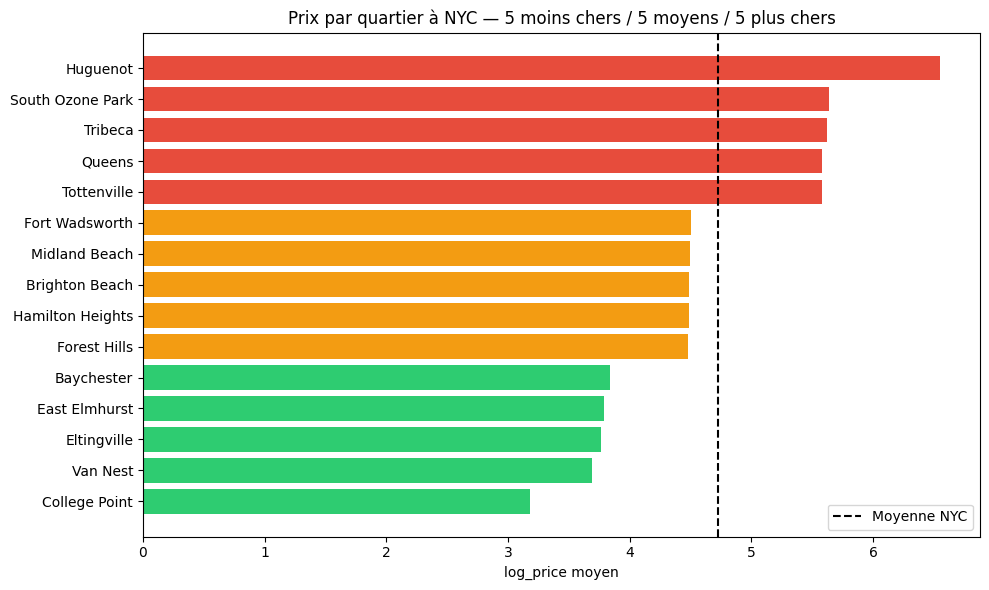

In [400]:
data_nyc = train_df[train_df['city'] == 'NYC']
prix_quartier = data_nyc.groupby('neighbourhood')['log_price'].mean().sort_values()

n = len(prix_quartier)
bas    = prix_quartier.iloc[:5]
moyens = prix_quartier.iloc[n//2 - 2 : n//2 + 3]
chers  = prix_quartier.iloc[-5:]

selection = pd.concat([bas, moyens, chers])
couleurs = ['#2ecc71']*5 + ['#f39c12']*5 + ['#e74c3c']*5

plt.figure(figsize=(10, 6))
plt.barh(selection.index, selection.values, color=couleurs)
plt.xlabel('log_price moyen')
plt.title('Prix par quartier à NYC — 5 moins chers / 5 moyens / 5 plus chers')
plt.axvline(data_nyc['log_price'].mean(), color='black', linestyle='--', label='Moyenne NYC')
plt.legend()
plt.tight_layout()
plt.show()

En se concentrant sur NYC, on observe des écarts de prix importants selon le quartier. Les quartiers les plus chers (Tribeca, Noho, Meatpacking District) ont des prix moyens bien supérieurs aux quartiers les moins chers. Cela confirme que le quartier est une variable pertinente pour prédire le prix, même si elle comporte beaucoup de modalités.

Graphique 6 — Boxplot prix par room_type :


/var/folders/r_/65dhf1995rs2srj0d2ywplw80000gn/T/ipykernel_2907/572870509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='room_type', y='log_price', order=order, palette='Set1')


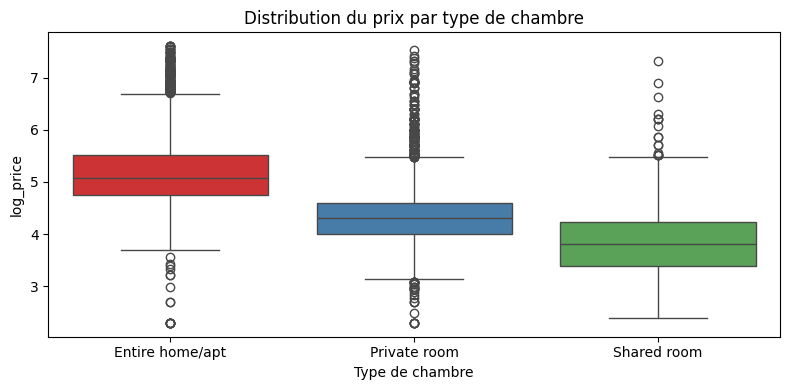

In [401]:
plt.figure(figsize=(8, 4))
order = train_df.groupby('room_type')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train_df, x='room_type', y='log_price', order=order, palette='Set1')
plt.xlabel('Type de chambre')
plt.ylabel('log_price')
plt.title('Distribution du prix par type de chambre')
plt.tight_layout()
plt.show()

Le type de chambre est l'une des variables les plus discriminantes. Les logements entiers (Entire home/apt) sont nettement plus chers que les chambres privées, elles-mêmes plus chères que les chambres partagées. Cette hiérarchie est très nette et confirme l'importance de cette variable pour la prédiction.

Graphique 7 — Boxplot prix par property_type (top 6) :


/var/folders/r_/65dhf1995rs2srj0d2ywplw80000gn/T/ipykernel_2907/2601612986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_top6, x='property_type', y='log_price', order=order, palette='Set3')


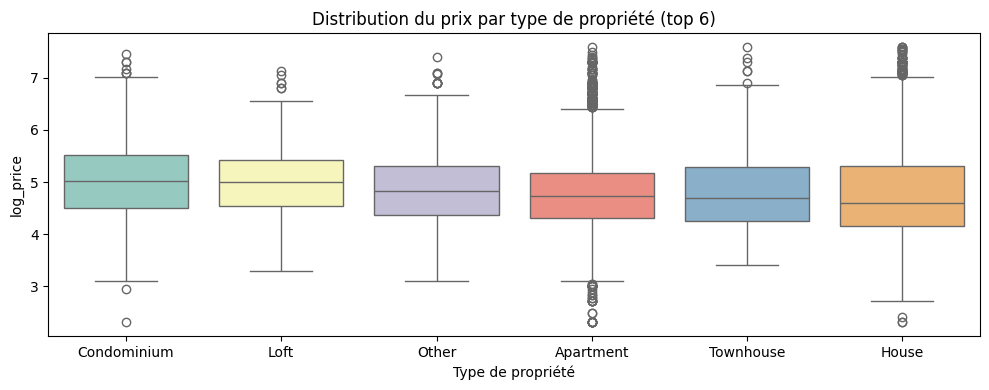

In [402]:
top6 = train_df['property_type'].value_counts().head(6).index
data_top6 = train_df[train_df['property_type'].isin(top6)]

plt.figure(figsize=(10, 4))
order = data_top6.groupby('property_type')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=data_top6, x='property_type', y='log_price', order=order, palette='Set3')
plt.xlabel('Type de propriété')
plt.ylabel('log_price')
plt.title('Distribution du prix par type de propriété (top 6)')
plt.tight_layout()
plt.show()

Parmi les types de propriété, les Condominiums et Lofts ont les prix médians les plus élevés, tandis que les Houses ont les prix les plus bas. Les différences sont moins marquées qu'avec le room_type, mais restent suffisamment significatives pour justifier de conserver cette variable.

Graphique 8 — Heatmap de corrélation :


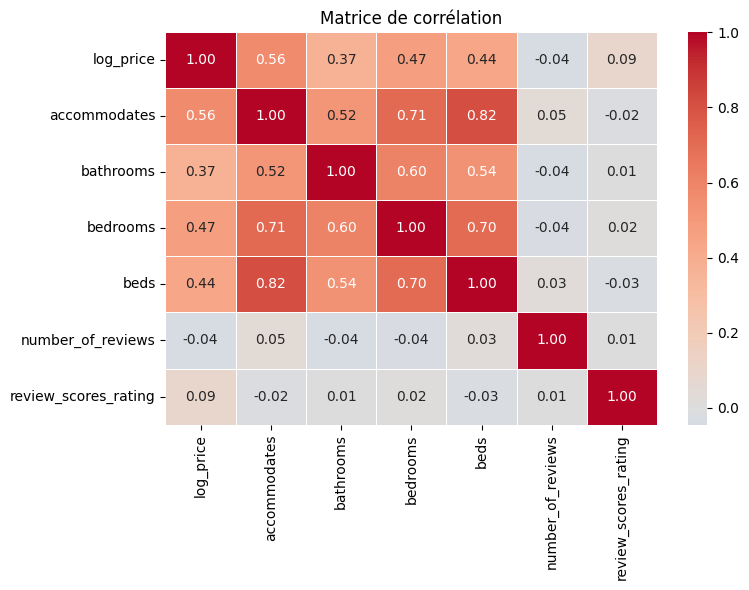

In [403]:
cols_numeriques = ['log_price', 'accommodates', 'bathrooms', 'bedrooms',
                   'beds', 'number_of_reviews', 'review_scores_rating']

plt.figure(figsize=(8, 6))
sns.heatmap(train_df[cols_numeriques].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

La matrice de corrélation révèle que accommodates est la variable numérique la plus corrélée au log_price (0.56), suivie de bedrooms (0.47) et beds (0.44). En revanche, review_scores_rating (0.09) et number_of_reviews (-0.04) sont très peu corrélés au prix. On note aussi que accommodates, bedrooms et beds sont très corrélés entre eux (multicolinéarité), ce que l'ACP permettra de gérer en créant des composantes non corrélées.

Graphique 9 — Scatter prix vs accommodates :


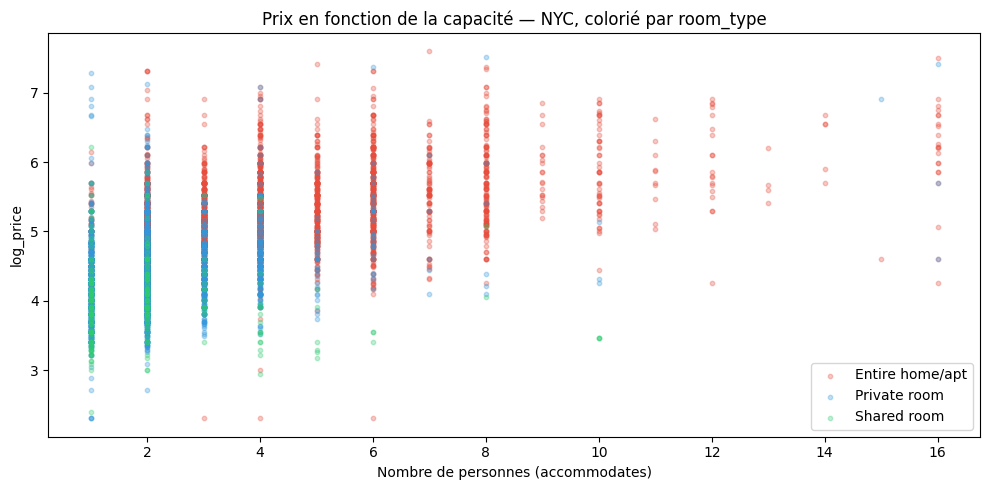

In [404]:
data_nyc = train_df[train_df['city'] == 'NYC']
couleurs = {'Entire home/apt': '#e74c3c', 'Private room': '#3498db', 'Shared room': '#2ecc71'}

plt.figure(figsize=(10, 5))
for room_type, groupe in data_nyc.groupby('room_type'):
    plt.scatter(groupe['accommodates'], groupe['log_price'],
                alpha=0.3, s=10, label=room_type,
                color=couleurs.get(room_type, 'gray'))

plt.xlabel('Nombre de personnes (accommodates)')
plt.ylabel('log_price')
plt.title('Prix en fonction de la capacité — NYC, colorié par room_type')
plt.legend()
plt.tight_layout()
plt.show()

En filtrant sur NYC et en coloriant par type de chambre, une tendance claire émerge : les logements entiers (rouge) sont systématiquement plus chers que les chambres privées (bleu) pour une même capacité. On observe aussi que la capacité a un effet positif sur le prix au sein de chaque catégorie. Ce graphique illustre bien l'interaction entre ces deux variables et confirme l'importance de les conserver toutes les deux pour la prédiction.

Graphique 10 — Scatter prix vs bedrooms :


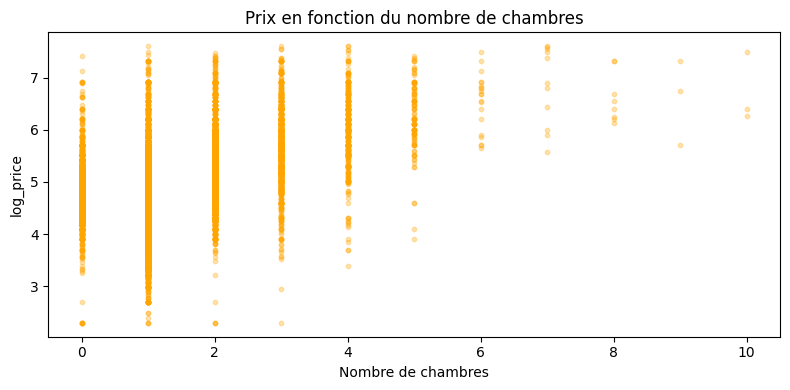

In [405]:
plt.figure(figsize=(8, 4))
plt.scatter(train_df['bedrooms'], train_df['log_price'],
            alpha=0.3, s=10, color='orange')
plt.xlabel('Nombre de chambres')
plt.ylabel('log_price')
plt.title('Prix en fonction du nombre de chambres')
plt.tight_layout()
plt.show()

Ce graphique montre une grande dispersion verticale pour chaque valeur de bedrooms : pour un même nombre de chambres, les prix varient énormément. La tendance positive est peu visible à l'œil nu. Cette variable sera donc utile au modèle mais insuffisante seule pour expliquer le prix.

Graphique 11 — Prix selon host_identity_verified :


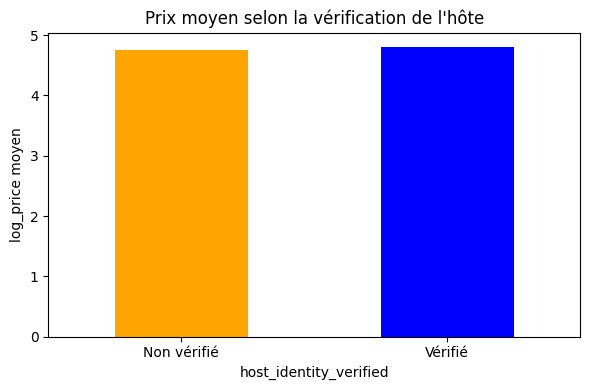

In [406]:
plt.figure(figsize=(6, 4))
train_df.groupby('host_identity_verified')['log_price'].mean().plot(
    kind='bar', color=['orange', 'blue'])
plt.xticks([0, 1], ['Non vérifié', 'Vérifié'], rotation=0)
plt.ylabel('log_price moyen')
plt.title('Prix moyen selon la vérification de l\'hôte')
plt.tight_layout()
plt.show()

La différence de prix moyen entre hôtes vérifiés et non vérifiés est très faible (environ 0.05 en log_price). Cette variable semble donc peu discriminante pour la prédiction du prix. 

Graphique 12 — Prix selon instant_bookable :


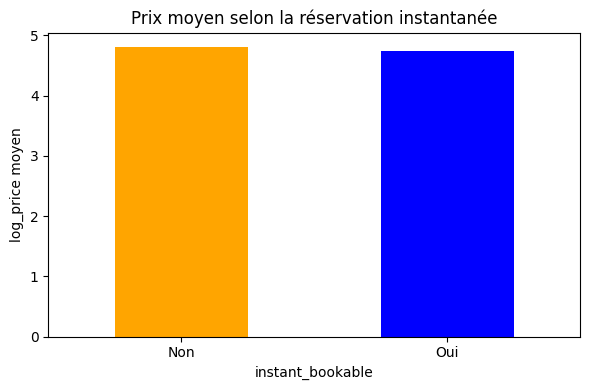

In [407]:
plt.figure(figsize=(6, 4))
train_df.groupby('instant_bookable')['log_price'].mean().plot(
    kind='bar', color=['orange', 'blue'])
plt.xticks([0, 1], ['Non', 'Oui'], rotation=0)
plt.ylabel('log_price moyen')
plt.title('Prix moyen selon la réservation instantanée')
plt.tight_layout()
plt.show()

De même, la différence entre logements avec et sans réservation instantanée est quasiment nulle. Cette variable n'apporte pas d'information significative sur le prix et aura probablement un faible impact dans le modèle de prédiction.

Graphique 13

/var/folders/r_/65dhf1995rs2srj0d2ywplw80000gn/T/ipykernel_2907/3058871708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='cancellation_policy', y='log_price', order=order, palette='Set2')


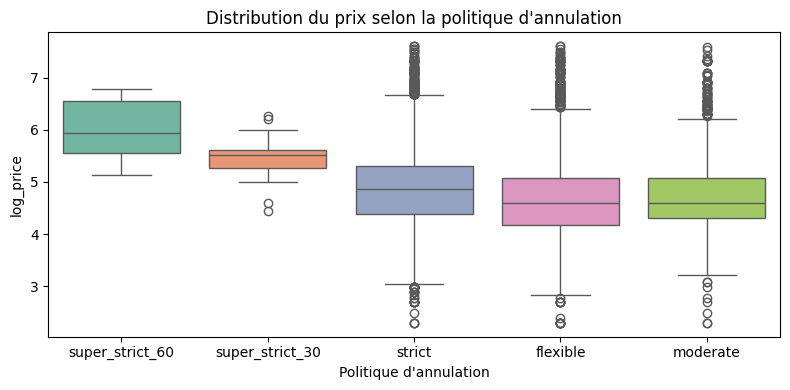

In [408]:
plt.figure(figsize=(8, 4))
order = train_df.groupby('cancellation_policy')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train_df, x='cancellation_policy', y='log_price', order=order, palette='Set2')
plt.xlabel('Politique d\'annulation')
plt.ylabel('log_price')
plt.title('Distribution du prix selon la politique d\'annulation')
plt.tight_layout()
plt.show()

Les logements avec une politique d'annulation stricte ont tendance à être plus chers que ceux avec une politique flexible. Cela s'explique probablement par le fait que les logements haut de gamme peuvent se permettre d'imposer des conditions plus strictes car la demande est forte.


## III) Prétraitement des données et Réduction de dimension
### a) Traitement des valeurs manquantes 

Avant toute analyse, on doit vérifier la présence de données manquantes. La plupart des algorithmes de Machine Learning (comme l'ACP) ne peuvent pas traiter les valeurs nulles.





In [409]:
print(train_df.isnull().sum())

id                           0
log_price                    0
property_type                0
room_type                    0
amenities                    0
accommodates                 0
bathrooms                   51
bed_type                     0
cancellation_policy          0
cleaning_fee                 0
city                         0
description                  0
first_review              4725
host_has_profile_pic        56
host_identity_verified      56
host_response_rate        5475
host_since                  56
instant_bookable             0
last_review               4716
latitude                     0
longitude                    0
name                         0
neighbourhood             2086
number_of_reviews            0
review_scores_rating      4978
zipcode                    303
bedrooms                    26
beds                        35
dtype: int64


On remarque donc qu'il manque beaucoup de valeurs. Nous allons donc adopter la stratégie suivante : 


- On **supprime** les colonnes textuelles qu'on ne peut pas exploiter simplement (description, name, amenities, first_review, last_review, host_since, zipcode)
- On **remplace** les trous par la **médiane** pour **les variables de structure** (bedrooms, beds, bathrooms) 
    car elle permet de remplir les trous avec la valeur la plus fréquente, ce qui est plus réaliste pour un appartement standard.
- On **remplace** les trous **par la moyenne** pour les **scores et taux** (review_scores_rating, host_response_rate)
    car elle est représentative de la performance globale de la plateforme et permet d'attribuer une valeur "neutre" sans pénaliser les hôtes.
- On **remplace par la valeur majoritaire** (vrai/faux) pour host_identity_verified
- On **encode** les colonnes catégorielles importantes (property_type, room_type, bed_type, cancellation_policy, city, neighbourhood) (section b)


Données manquantes vrai/faux liées au profil de l'hôte:

In [410]:

print(train_df["host_identity_verified"].value_counts())

host_identity_verified
t    14953
f     7225
Name: count, dtype: int64


On a remplace donc les trous par t pour les deux. Il faut ensuite remplacer t par 1 et f par 0.

**Finalement, on a :**

In [411]:
var_struct = ["bedrooms", "beds", "bathrooms"]
scores_taux = ["review_scores_rating", "host_response_rate"]
col_supp = ["description", "name", "amenities", "first_review", "last_review", "host_since", "zipcode", "host_has_profile_pic"]

In [412]:

# Médiane pour les variables de structure
for col in var_struct:
    train_df[col] = train_df[col].fillna(train_df[col].median())

# Moyenne pour les scores et taux
if train_df['host_response_rate'].dtype == 'object':
    train_df['host_response_rate'] = train_df['host_response_rate'].str.replace('%', '').astype(float)

for col in scores_taux:
    train_df[col] = train_df[col].fillna(train_df[col].mean())

# Suppression des colonnes inutilisables
train_df = train_df.drop(columns=col_supp, errors='ignore')

# Valeur majoritaire pour host_identity_verified
train_df["host_identity_verified"] = train_df["host_identity_verified"].fillna("t")


In [413]:
print(train_df.isnull().sum())

id                           0
log_price                    0
property_type                0
room_type                    0
accommodates                 0
bathrooms                    0
bed_type                     0
cancellation_policy          0
cleaning_fee                 0
city                         0
host_identity_verified       0
host_response_rate           0
instant_bookable             0
latitude                     0
longitude                    0
neighbourhood             2086
number_of_reviews            0
review_scores_rating         0
bedrooms                     0
beds                         0
dtype: int64


Il n'y a plus de données manquantes, on passe donc à l'étape d'après. (appart pour la colonne **neighbourhood** lais on a jugé important de garder cette colonne dans notre étude)

### b) Encodage 


On encode les variables catégorielles importantes plutôt que de les supprimer. Le `LabelEncoder` transforme chaque catégorie en un entier (ex: "Apartment" → 0, "House" → 1...). 

On conserve ainsi l'information contenue dans ces colonnes pour le modèle.

In [414]:
from sklearn.preprocessing import LabelEncoder

cols_a_encoder = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city', 'neighbourhood']

encoders = {}
for col in cols_a_encoder:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].fillna('Unknown').astype(str))
    encoders[col] = le  # sauvegardé pour appliquer le même encodage au test plus tard

# Encodage binaire de host_identity_verified
train_df["host_identity_verified"] = train_df["host_identity_verified"].map({'t': 1, 'f': 0}).fillna(0).astype(int)



In [415]:
# Suppression des colonnes object restantes
train_df = train_df.select_dtypes(exclude=['object'])

print("Colonnes restantes :", list(train_df.columns))
print("Shape :", train_df.shape)

Colonnes restantes : ['id', 'log_price', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_identity_verified', 'host_response_rate', 'latitude', 'longitude', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds']
Shape : (22234, 19)


### c) Standardisation

On standardise les données pour que chaque variable ait une moyenne de 0 et un écart-type de 1. C'est indispensable avant l'ACP : sans ça, les variables avec de grandes valeurs numériques domineraient l'analyse même si elle peuvent être moins pertinentes que d'autres valeurs 

In [416]:
from sklearn.preprocessing import StandardScaler

# On sépare log_price avant de standardiser
train_features = train_df.drop(columns=['log_price'])
y_log_price = train_df['log_price']

# On fitte le scaler uniquement sur les features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(train_features)
train_df_scaled = pd.DataFrame(data_scaled, columns=train_features.columns)
train_df_scaled.head()

,id,log_price,property_type,room_type,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,host_identity_verified,host_response_rate,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,bedrooms,beds
0,-0.906873,-0.648345,1.32514,0.944570,-0.072568,-0.402096,0.151679,-1.330693,-1.676831,-0.247632,-1.441309,-1.019291e-15,-1.523715,-1.193613,-0.106306,-0.555922,4.145693e-15,-1.483500,0.230941
1,0.536305,-1.079870,1.32514,0.944570,0.393889,1.305353,0.151679,1.008634,-1.676831,0.598771,0.693814,3.954679e-01,0.730072,0.847264,0.611807,0.466054,-1.176985e+00,-0.310272,0.230941
2,-0.133223,3.209212,-0.67776,-0.853355,1.326802,1.305353,0.151679,-1.330693,-1.676831,-1.094035,-1.441309,-1.019291e-15,0.147989,0.703181,1.113346,-0.555922,4.145693e-15,0.862957,0.230941
3,1.107120,-1.708725,1.32514,0.944570,-1.005481,-0.402096,0.151679,-1.330693,0.596363,0.598771,0.693814,3.954679e-01,0.740013,0.846581,0.965164,-0.044934,2.816514e-01,-0.310272,-0.566378
4,-0.206059,0.969970,1.32514,-0.853355,0.393889,-0.402096,0.151679,-0.161030,0.596363,1.445174,0.693814,3.954679e-01,-0.233778,-1.391875,0.258449,-0.152510,2.816514e-01,0.862957,0.230941


### d) ACP (Analyse en Composantes Principales)

Les données standardisées contiennent encore beaucoup de variables potentiellement corrélées entre elles (on a vu par exemple que accommodates, bedrooms et beds sont très liées). L'ACP va nous permettre de réduire la dimension en créant des composantes non corrélées, tout en conservant le maximum de variance. On commence par déterminer combien de composantes garder grâce au graphique de variance expliquée cumulée.

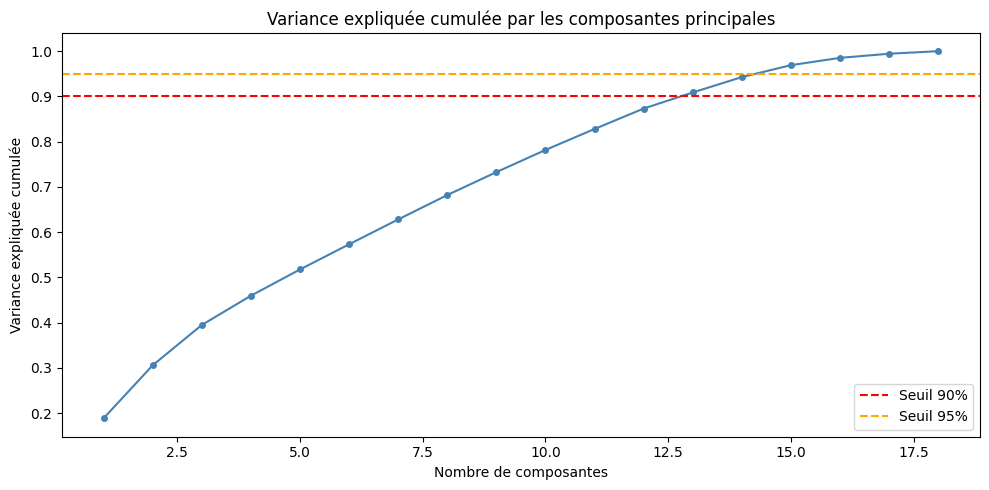

Composantes nécessaires pour 90% de variance : 13
Composantes nécessaires pour 95% de variance : 15


In [417]:
from sklearn.decomposition import PCA

# On sépare X (features) et y (cible) avant l'ACP
y_train = y_log_price
X_train_scaled = train_df_scaled

# On applique l'ACP sur toutes les composantes pour voir la variance expliquée
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Variance expliquée cumulée
variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, marker='o', markersize=4, color='steelblue')
plt.axhline(y=0.90, color='red', linestyle='--', label='Seuil 90%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='Seuil 95%')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance expliquée cumulée par les composantes principales')
plt.legend()
plt.tight_layout()
plt.show()

# Affichage du nombre de composantes nécessaires
for seuil in [0.90, 0.95]:
    n = np.argmax(variance_cumulee >= seuil) + 1
    print(f"Composantes nécessaires pour {int(seuil*100)}% de variance : {n}")

La courbe de variance expliquée cumulée monte progressivement sans rupture nette, ce qui indique que l'information est bien distribuée entre les variables. Il faut 13 composantes pour atteindre 90% de variance expliquée. On choisit ce seuil comme compromis entre réduction de dimension et conservation de l'information.

In [418]:
# On applique l'ACP avec 13 composantes (seuil 90%)
n_composantes = 13
pca = PCA(n_components=n_composantes)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Dimensions avant ACP : {X_train_scaled.shape}")
print(f"Dimensions après ACP : {X_pca.shape}")
print(f"Variance expliquée totale : {pca.explained_variance_ratio_.sum():.2%}")

Dimensions avant ACP : (22234, 18)
Dimensions après ACP : (22234, 13)
Variance expliquée totale : 90.88%


## IV) Prédiction

On teste plusieurs modèles dans l'ordre croissant de complexité. Pour chaque modèle on calcule le R² sur l'ensemble d'entraînement et de validation afin de détecter un éventuel surapprentissage. On commence par définir une baseline : prédire toujours la moyenne du log_price. C'est le score minimal à dépasser pour que notre modèle soit utile.

In [419]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

# Séparation features / cible
X = X_pca  # données projetées par l'ACP
y = y_train.values  # log_price

# Train / Validation split (75% / 25%)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

# Baseline : toujours prédire la moyenne
baseline_pred = np.full(len(y_val), y_tr.mean())
r2_baseline = r2_score(y_val, baseline_pred)
print(f"Baseline R² : {r2_baseline:.4f}")

Baseline R² : -0.0002


Modèle 1) Régression linéaire :

In [420]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_tr, y_tr)

r2_lr_train = r2_score(y_tr, lr.predict(X_tr))
r2_lr_val   = r2_score(y_val, lr.predict(X_val))
print(f"Régression Linéaire  R² train : {r2_lr_train:.4f}  |  R² val : {r2_lr_val:.4f}")

Régression Linéaire  R² train : 0.4583  |  R² val : 0.4468


Modèle 2) Ridge :

In [421]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr, y_tr)

r2_ridge_train = r2_score(y_tr, ridge.predict(X_tr))
r2_ridge_val   = r2_score(y_val, ridge.predict(X_val))
print(f"Ridge  R² train : {r2_ridge_train:.4f}  |  R² val : {r2_ridge_val:.4f}")

Ridge  R² train : 0.4583  |  R² val : 0.4468


Modèle 3) LinearSVR :

In [422]:
from sklearn.svm import LinearSVR

svr = LinearSVR(max_iter=2000)
svr.fit(X_tr, y_tr)

r2_svr_train = r2_score(y_tr, svr.predict(X_tr))
r2_svr_val   = r2_score(y_val, svr.predict(X_val))
print(f"LinearSVR  R² train : {r2_svr_train:.4f}  |  R² val : {r2_svr_val:.4f}")

LinearSVR  R² train : 0.4517  |  R² val : 0.4417


/Users/m1/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Modèle 4)
 Arbre de décision :


In [423]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
dt.fit(X_tr, y_tr)

r2_dt_train = r2_score(y_tr, dt.predict(X_tr))
r2_dt_val   = r2_score(y_val, dt.predict(X_val))
print(f"Arbre de décision  R² train : {r2_dt_train:.4f}  |  R² val : {r2_dt_val:.4f}")

Arbre de décision  R² train : 0.6187  |  R² val : 0.4251


Modèle 5) Random Forest :


In [424]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

r2_rf_train = r2_score(y_tr, rf.predict(X_tr))
r2_rf_val   = r2_score(y_val, rf.predict(X_val))
print(f"Random Forest  R² train : {r2_rf_train:.4f}  |  R² val : {r2_rf_val:.4f}")

Random Forest  R² train : 0.6758  |  R² val : 0.5244


Modèle 6) Gradient Boosting :


In [425]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
gb.fit(X_tr, y_tr)

r2_gb_train = r2_score(y_tr, gb.predict(X_tr))
r2_gb_val   = r2_score(y_val, gb.predict(X_val))
print(f"Gradient Boosting  R² train : {r2_gb_train:.4f}  |  R² val : {r2_gb_val:.4f}")

Gradient Boosting  R² train : 0.6427  |  R² val : 0.5318


### Comparaison des modèles

On récapitule les performances de tous les modèles testés. Le R² mesure la proportion de variance expliquée par le modèle : 1 est parfait, 0 équivaut à prédire la moyenne (notre baseline), négatif est pire que la baseline.

                     R² train  R² val
Baseline               0.0000 -0.0002
Régression Linéaire    0.4583  0.4468
Ridge                  0.4583  0.4468
LinearSVR              0.4517  0.4417
Arbre de décision      0.6187  0.4251
Random Forest          0.6758  0.5244
Gradient Boosting      0.6427  0.5318


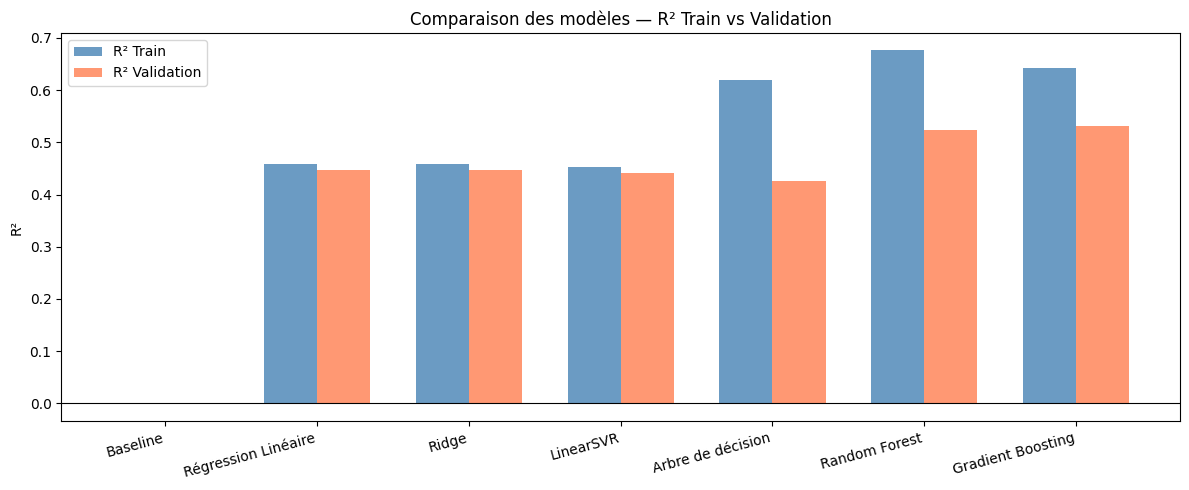

In [426]:
import matplotlib.pyplot as plt
import pandas as pd

resultats = {
    'Baseline':           {'R² train': 0.0,    'R² val': r2_baseline},
    'Régression Linéaire':{'R² train': r2_lr_train,    'R² val': r2_lr_val},
    'Ridge':              {'R² train': r2_ridge_train,  'R² val': r2_ridge_val},
    'LinearSVR':          {'R² train': r2_svr_train,    'R² val': r2_svr_val},
    'Arbre de décision':  {'R² train': r2_dt_train,     'R² val': r2_dt_val},
    'Random Forest':      {'R² train': r2_rf_train,     'R² val': r2_rf_val},
    'Gradient Boosting':  {'R² train': r2_gb_train,     'R² val': r2_gb_val},
}

df_resultats = pd.DataFrame(resultats).T
print(df_resultats.round(4))

# Visualisation
x = range(len(df_resultats))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], df_resultats['R² train'], width, label='R² Train', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], df_resultats['R² val'],   width, label='R² Validation', color='coral', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(df_resultats.index, rotation=15, ha='right')
ax.set_ylabel('R²')
ax.set_title('Comparaison des modèles — R² Train vs Validation')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Ce graphique montre pour chaque modèle deux barres :

- La bleue = le score sur les données que le modèle a vues pendant l'entraînement.
- La rouge = le score sur des données nouvelles qu'il n'a jamais vues

Ce qu'on en conclut :
- Si les deux barres sont proches → le modèle généralise bien, il n'a pas appris par cœur.
- Si la bleue est beaucoup plus haute que la rouge → surapprentissage (overfitting) — le modèle a mémorisé le train mais ne sait pas généraliser. C'est ce qu'on voit clairement sur l'arbre de décision (0.62 vs 0.43).
- Si les deux barres sont basses → le modèle est trop simple, il ne capture pas les relations dans les données. C'est ce qu'on voit sur les modèles linéaires.

Le meilleur modèle est celui qui a la barre rouge la plus haute avec un écart raisonnable entre les deux — c'est le Gradient Boosting.

### Visualisation des prédictions sur le train

On visualise la qualité des prédictions du Gradient Boosting sur les données d'entraînement en comparant les valeurs prédites aux valeurs réelles. Un modèle parfait aurait tous les points sur la diagonale rouge.

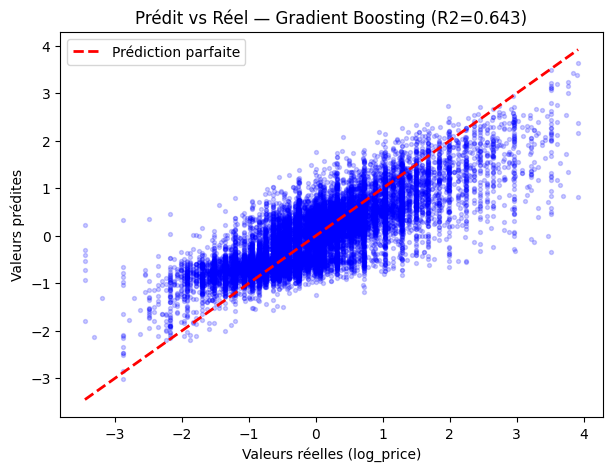

In [427]:
y_pred_train = gb.predict(X_tr)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y_tr, y_pred_train, alpha=0.2, s=8, color='blue')

ax.plot([y_tr.min(), y_tr.max()],
        [y_tr.min(), y_tr.max()],
        color='red', linestyle='--', lw=2,
        label='Prédiction parfaite')

ax.set_xlabel('Valeurs réelles (log_price)')
ax.set_ylabel('Valeurs prédites')

ax.set_title(f'Prédit vs Réel — Gradient Boosting (R2={r2_gb_train:.3f})')

ax.legend()

plt.show()

On observe que les points se concentrent bien autour de la diagonale, avec une dispersion plus importante aux extrêmes (logements très bon marché ou très chers), ce qui est typique des modèles de régression sur des prix immobiliers. 

### Analyse des résultats

Le graphique de comparaison montre une progression claire des performances :
- La **baseline** (R²≈0) confirme qu'un modèle naïf n'explique rien.
- Les **modèles linéaires** (Régression Linéaire, Ridge, LinearSVR) atteignent tous un R² validation autour de 0.44-0.45. Leurs performances quasi-identiques s'expliquent par le fait que l'ACP a déjà éliminé la multicolinéarité, rendant la régularisation de Ridge inutile.
- L'**arbre de décision** montre du surapprentissage marqué (0.62 train vs 0.43 val) : modèle trop expressif comme mentionné dans le cours.
- Le **Random Forest** et le **Gradient Boosting** sont les meilleurs modèles avec un R² validation autour de 0.52-0.53, avec un surapprentissage bien maitrisé.
- Le **Gradient Boosting** est retenu comme modèle final car il obtient le meilleur R² validation (0.5318) avec le plus faible écart train/val des modèles ensemblistes.

/var/folders/r_/65dhf1995rs2srj0d2ywplw80000gn/T/ipykernel_2907/662641329.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(modeles, rotation=20, ha='right')
/var/folders/r_/65dhf1995rs2srj0d2ywplw80000gn/T/ipykernel_2907/662641329.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(modeles, rotation=20, ha='right')


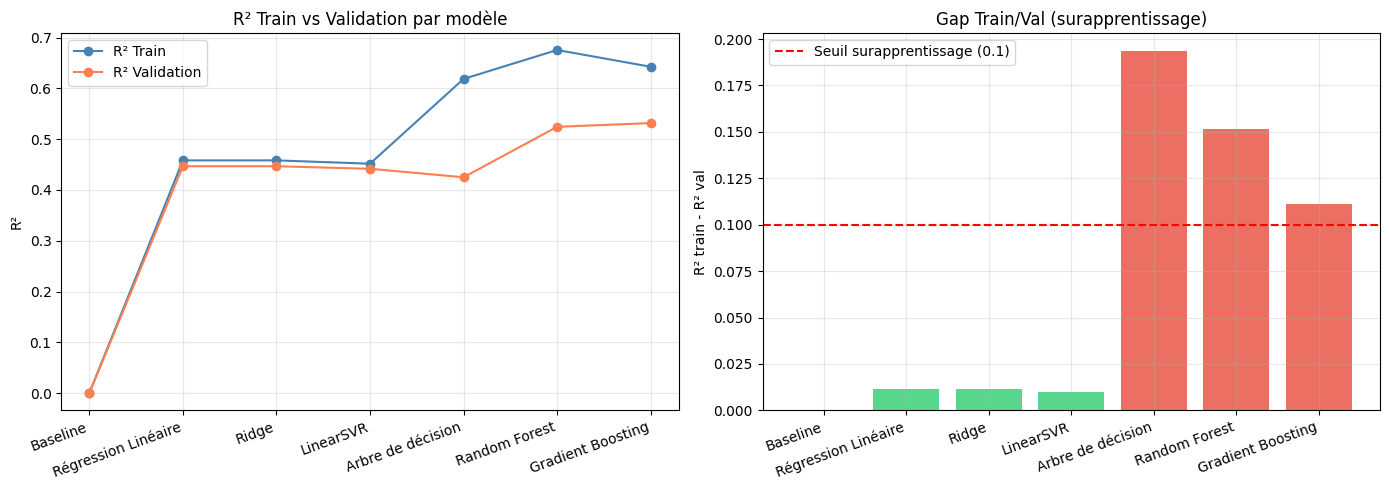

In [428]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modeles = list(df_resultats.index)
r2_train = df_resultats['R² train'].values
r2_val = df_resultats['R² val'].values

# Graphique 1 : R² train vs val
axes[0].plot(modeles, r2_train, marker='o', label='R² Train', color='steelblue')
axes[0].plot(modeles, r2_val, marker='o', label='R² Validation', color='coral')
axes[0].set_title('R² Train vs Validation par modèle')
axes[0].set_ylabel('R²')
axes[0].set_xticklabels(modeles, rotation=20, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : gap surapprentissage
gap = r2_train - r2_val
colors = ['#e74c3c' if g > 0.1 else '#2ecc71' for g in gap]
axes[1].bar(modeles, gap, color=colors, alpha=0.8)
axes[1].axhline(y=0.1, color='red', linestyle='--', label='Seuil surapprentissage (0.1)')
axes[1].set_title('Gap Train/Val (surapprentissage)')
axes[1].set_ylabel('R² train - R² val')
axes[1].set_xticklabels(modeles, rotation=20, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## IV. Prédiction finale

On retient le **Gradient Boosting** comme meilleur modèle (R² val = 0.5318). On applique maintenant exactement le même prétraitement au fichier test avant de générer les prédictions.

In [429]:
# Chargement du fichier test
df_test = test_df.copy()

# 1. Suppression des colonnes inutilisables
df_test = df_test.drop(columns=col_supp, errors='ignore')

# 2. Remplacement des valeurs manquantes
for col in var_struct:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(df_test[col].median())

if df_test['host_response_rate'].dtype == 'object':
    df_test['host_response_rate'] = df_test['host_response_rate'].str.replace('%', '').astype(float)

for col in scores_taux:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(df_test[col].mean())

df_test["host_identity_verified"] = df_test["host_identity_verified"].fillna("t")

# 3. Encodage avec les mêmes encodeurs que le train
for col in cols_a_encoder:
    if col in df_test.columns:
        le = encoders[col]
        vals = df_test[col].fillna('Unknown').astype(str)
        df_test[col] = vals.apply(lambda x: int(le.transform([x])[0]) if x in le.classes_ else -1)

# 4. Encodage binaire
df_test["host_identity_verified"] = df_test["host_identity_verified"].map({'t': 1, 'f': 0}).fillna(0).astype(int)

# 5. Suppression colonnes object restantes
df_test = df_test.select_dtypes(exclude=['object'])

# 6. Alignement sur les colonnes du train SANS log_price
for col in X_train_scaled.columns:
    if col not in df_test.columns:
        df_test[col] = 0
df_test = df_test[X_train_scaled.columns]

# 7. Standardisation avec le même scaler que le train
X_test_scaled = pd.DataFrame(
    scaler.transform(df_test),
    columns=df_test.columns
)

# 8. ACP avec le même pca
X_test_pca = pca.transform(X_test_scaled)

print(f"Shape test après prétraitement : {X_test_pca.shape}")

Shape test après prétraitement : (51877, 13)


Prédiction et sauvegarde :

In [432]:
# Prédiction avec le Gradient Boosting
y_pred_final = gb.predict(X_test_pca)

# Sauvegarde au format attendu
prediction_example = pd.read_csv('prediction_example.csv')
prediction_example['logpred'] = y_pred_final
prediction_example.to_csv('MaPredictionFinale.csv', index=False)

print("Fichier de prédiction sauvegardé !")
print(prediction_example.head())
print(prediction_example['logpred'].describe())

Fichier de prédiction sauvegardé !
   Unnamed: 0   logpred
0    14282777  2.046780
1    17029381  1.464664
2     7824740  1.137589
3    19811650  1.534118
4    12410741  2.124736
count    51877.000000
mean         1.622795
std          0.312292
min         -0.598620
25%          1.534118
50%          1.534118
75%          1.718178
max          3.922277
Name: logpred, dtype: float64


Vérification conformité :

In [431]:
def estConforme(monFichier_csv):
    votre_prediction = pd.read_csv(monFichier_csv)
    fichier_exemple = pd.read_csv('prediction_example.csv')

    assert votre_prediction.columns[1] == fichier_exemple.columns[1], \
        f"La colonne doit s'appeler '{fichier_exemple.columns[1]}'"
    assert len(votre_prediction) == len(fichier_exemple), \
        f"Vous devriez avoir {len(fichier_exemple)} prédictions"
    assert np.all(votre_prediction.iloc[:,0] == fichier_exemple.iloc[:,0])

    print("Fichier conforme !")

estConforme('MaPredictionFinale.csv')

Fichier conforme !


## Conclusion

### Récapitulatif de la démarche

**Exploration qualitative (1/3 du projet) :**
Nous avons analysé les distributions, corrélations et relations entre variables via plusieurs graphiques. Les variables les plus influentes sur le prix sont : le type de chambre (room_type), la capacité (accommodates), la ville (city) et le quartier (neighbourhood).

**Prétraitement :**
- Traitement des valeurs manquantes (médiane, moyenne, valeur majoritaire)
- Encodage des variables catégorielles importantes (LabelEncoder)
- Standardisation (StandardScaler)
- Réduction de dimension par ACP : 13 composantes retenues pour 90% de variance expliquée

**Prédiction :**
Nous avons testé 7 modèles de complexité croissante. Le Gradient Boosting est retenu comme meilleur modèle avec un R² validation de 0.5318, soit une amélioration de +53% par rapport à la baseline.

| Modèle | R² Validation |
|--------|--------------|
| Baseline | ~0.00 |
| Régression Linéaire | 0.4468 |
| Ridge | 0.4468 |
| LinearSVR | 0.4422 |
| Arbre de décision | 0.4251 |
| Random Forest | 0.5244 |
| **Gradient Boosting** | **0.5318** |

### Pistes d'amélioration
- Extraction des équipements depuis la colonne amenities
